# Johansen CO₂ Storage — Injection Rate Sensitivity Study
## Comprehensive Exploratory Data Analysis (Layer-Resolved)

**Simulation runs at different CO₂ injection rates (doubling each run)**

**Sections:**
1. Data Loading & Catalogue
2. Geographic Map — Click a Well to Explore Data (Layer-by-Layer)
3. Injection Rate Sensitivity — Injector Pressure & Saturation
4. Pressure Propagation Across Observation Wells
5. Formation Capacity Analysis (Peak Pressure vs Rate)
6. Scenario × Well Heatmap
7. Pressure Recovery Time Analysis
8. Interactive Multi-Well Explorer

In [1]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output
warnings.filterwarnings('ignore')

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'well_csvs'))
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
if not os.path.exists(BASE_DIR):
    BASE_DIR = '/Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a/core/examples/data/Johansen/well_csvs'
    DATA_DIR = '/Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a/core/examples/data/Johansen/data'
WELL_LOC_FILE = os.path.join(DATA_DIR, 'well_loc.csv')

print(f'Base CSVs : {BASE_DIR}')
print(f'Data dir  : {DATA_DIR}')

Base CSVs : /Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a/core/examples/data/Johansen/well_csvs
Data dir  : /Users/apple/Desktop/study/programming/Matlab/Plugins/MRST-2026a/core/examples/data/Johansen/data


In [2]:
# ── 1. Data Loading & Catalogue ────────────────────────────────────────────

def parse_summary(path):
    result = {'active_wells': {}, 'obs_wells': {}, 'meta': {}}
    if not os.path.exists(path):
        return result
    with open(path) as f:
        lines = f.readlines()
    mode = None
    for line in lines:
        s = line.strip()
        for key, tag in [('co2_total','Total CO2 injected'), ('brine_total','Total brine produced'),
                         ('peak_bhp','Peak injector BHP'), ('sim_window','Simulation window'),
                         ('inj_end','Injection end year')]:
            if tag in s:
                result['meta'][key] = s.split(':')[-1].strip()
        if '--- ACTIVE PLAN WELLS' in s:   mode = 'plan'; continue
        if '--- MASS BALANCE' in s:         mode = None;   continue
        if '--- OBSERVATION WELLS' in s:    mode = 'obs';  continue
        if '--- CSV COLUMN' in s:           mode = None;   continue
        if mode == 'plan':
            if not s or s.startswith('Well') or s.startswith('---'): continue
            role = 'Injector' if 'Injector' in s else ('Producer' if 'Producer' in s else None)
            if role:
                wname = s.split(role)[0].strip()
                try:    rate_val = float(s.split('Mt/yr')[0].split()[-1])
                except: rate_val = 0.0
                result['active_wells'][wname] = {'role': role, 'rate_mtyr': rate_val}
        elif mode == 'obs':
            if not s or s.startswith('Well') or s.startswith('---'): continue
            parts = s.split()
            if len(parts) >= 7:
                wname = ' '.join(parts[:-6])
                result['obs_wells'][wname] = {
                    'GridI': int(parts[-6]), 'GridJ': int(parts[-5]),
                    'depth_m': float(parts[-2]), 'csv': parts[-1]
                }
    return result

run_folders = sorted([f for f in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, f))])
runs = {}
for rf in run_folders:
    rfpath  = os.path.join(BASE_DIR, rf)
    summary = parse_summary(os.path.join(rfpath, 'simulation_summary.txt'))
    if not summary['obs_wells']: continue # skip invalid/empty folders
    
    rate_val   = 0.0
    rate_label = 'Unknown'
    for aw in summary['active_wells'].values():
        if aw['role'] == 'Injector' and aw['rate_mtyr'] > 0:
            rate_val   = aw['rate_mtyr']
            rate_label = f"{aw['rate_mtyr']:.1f} Mt/yr"
    
    well_dfs = {}
    for wname, winfo in summary['obs_wells'].items():
        csv_path = os.path.join(rfpath, winfo['csv'])
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            
            # Handle layer-by-layer data format
            p_cols = [c for c in df.columns if c.startswith('P_bar_L')]
            s_cols = [c for c in df.columns if c.startswith('S_CO2_L')]
            
            # Compute fallback means over layers for backward compatibility in overall plots
            if p_cols:
                df['Pressure_bar'] = df[p_cols].mean(axis=1)
            if s_cols:
                df['CO2_Saturation'] = df[s_cols].mean(axis=1)
                
            df['Well']       = wname
            df['Run']        = rf
            df['Rate_label'] = rate_label
            well_dfs[wname]  = df
            
    runs[rf] = {
        'label': rate_label, 'rate_val': rate_val,
        'meta': summary['meta'],
        'active_wells': summary['active_wells'],
        'obs_wells':    summary['obs_wells'],
        'dfs':          well_dfs
    }

all_dfs = pd.concat(
    [df for rd in runs.values() for df in rd['dfs'].values()],
    ignore_index=True
)

print(f'Loaded {len(runs)} valid simulation runs  |  Total records: {len(all_dfs):,}')
print()
print(f'  {"Run Folder":<28} {"Inj Rate":>12}  {"Total CO2":>18}  {"Peak BHP":>14}')
print('  ' + '-'*78)
for rf, rd in runs.items():
    m = rd['meta']
    print(f'  {rf:<28} {rd["label"]:>12}  {m.get("co2_total","N/A"):>18}  {m.get("peak_bhp","N/A"):>14}')

Loaded 9 valid simulation runs  |  Total records: 13,560

  Run Folder                       Inj Rate           Total CO2        Peak BHP
  ------------------------------------------------------------------------------
  31_07_2026__22_16               2.0 Mt/yr         679.2000 Mt      897.41 bar
  31_07_2026__22_21               2.0 Mt/yr         636.9500 Mt      953.43 bar
  31_07_2026__22_28               2.0 Mt/yr         611.8500 Mt      884.72 bar
  31_07_2026__22_33               2.0 Mt/yr         669.0000 Mt      723.48 bar
  31_07_2026__22_37               2.0 Mt/yr         329.6500 Mt      857.86 bar
  31_07_2026__22_41               2.0 Mt/yr         710.2000 Mt     1074.58 bar
  31_07_2026__22_46               2.0 Mt/yr         691.4000 Mt      816.49 bar
  31_07_2026__22_50               2.0 Mt/yr         337.7000 Mt      935.46 bar
  31_07_2026__22_53               2.0 Mt/yr        1485.2000 Mt      991.65 bar


In [3]:
# ── 2. Geographic Map — Click a Well to Explore Data (Layer-by-Layer) ─────

# Latest run for status reference
latest_run = list(runs.keys())[-1]
latest     = runs[latest_run]

# Extract wells directly from the latest simulation summary 
# (this guarantees hardcoded/synthetic wells like NBounndary_test_well are included)
refLat, refLon, refI, refJ = 60.576425, 3.443367, 51, 51
scaleI, scaleJ = 55.5 / 0.9, 111.0 / 0.9

loc_data = []
for wname, winfo in latest['obs_wells'].items():
    gI, gJ = winfo['GridI'], winfo['GridJ']
    lon = refLon + (gI - refI) / scaleI
    lat = refLat + (gJ - refJ) / scaleJ
    
    role = 'In-Reservoir (Obs)'
    if wname in latest['active_wells']:
        role = 'Active ' + latest['active_wells'][wname]['role']
        
    loc_data.append({'Well_Bore_Name': wname, 'GridI': gI, 'GridJ': gJ, 
                     'EW_DEC_DEG': lon, 'NS_DEC_DEG': lat, 'Status': role})

df_loc = pd.DataFrame(loc_data)

# Status priority score for deduplication (lower = higher priority)
STATUS_PRIORITY = {'Active Injector': 0, 'Active Producer': 1, 'In-Reservoir (Obs)': 2}
df_loc['Priority'] = df_loc['Status'].map(STATUS_PRIORITY)

# Deduplicate exact lat/lon (GridI, GridJ)
df_loc = df_loc.sort_values('Priority')
df_dedup = df_loc.drop_duplicates(subset=['GridI', 'GridJ'], keep='first').copy()

# Build alias map
loc_to_all = {}
for (gI, gJ), grp in df_loc.groupby(['GridI', 'GridJ']):
    all_names = grp['Well_Bore_Name'].tolist()
    rep_name  = df_dedup.loc[(df_dedup['GridI']==gI) & (df_dedup['GridJ']==gJ), 'Well_Bore_Name'].values[0]
    loc_to_all[rep_name] = all_names

print(f'Total observation locations mapped: {len(df_dedup)} unique grid blocks')
for rep, all_names in loc_to_all.items():
    if len(all_names) > 1:
        print(f'  Rep: {rep:20s} | Aliases: {[n for n in all_names if n!=rep]}')

# ── Build Map Widget ──────────────────────────────────────────────────────
style = {
    'Active Injector':    {'color': '#d62728', 'symbol': 'triangle-up', 'size': 16},
    'Active Producer':    {'color': '#1f77b4', 'symbol': 'square',       'size': 16},
    'In-Reservoir (Obs)': {'color': '#2ca02c', 'symbol': 'circle',       'size': 11},
}

fig_map = go.FigureWidget()
for status, s in style.items():
    sub = df_dedup[df_dedup['Status'] == status]
    if sub.empty: continue
    
    hover_texts, custom_data = [], []
    for _, row in sub.iterrows():
        wname = row['Well_Bore_Name']
        aliases = loc_to_all.get(wname, [wname])
        coinc_str = f'<br>⚠️ Aliases: {", ".join([n for n in aliases if n != wname])}' if len(aliases)>1 else ''
        
        hover_texts.append(
            f'<b>{wname}</b><br>'
            f'Status: <b>{status}</b><br>'
            f'Grid: ({row["GridI"]}, {row["GridJ"]})<br>'
            f'Lat {row["NS_DEC_DEG"]:.5f}°N  Lon {row["EW_DEC_DEG"]:.5f}°E'
            f'{coinc_str}<br><i>Click to explore layer data</i>'
        )
        custom_data.append([wname])
        
    fig_map.add_trace(go.Scatter(
        x=sub['EW_DEC_DEG'], y=sub['NS_DEC_DEG'], mode='markers+text',
        name=status, text=sub['Well_Bore_Name'], textposition='top center',
        hovertext=hover_texts, hoverinfo='text', customdata=custom_data,
        marker=dict(size=s['size'], color=s['color'], symbol=s['symbol'], line=dict(width=1.5, color='black'))
    ))

fig_map.update_layout(
    title='<b>Johansen Formation — In-Reservoir Wells</b>',
    xaxis_title='Longitude (°E)', yaxis_title='Latitude (°N)',
    template='plotly_white', height=550,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.9)', borderwidth=1), margin=dict(t=50, b=40)
)

# ── Click Explorer Controls & Logic ───────────────────────────────────────
w_layer = widgets.Dropdown(options=['Mean All Layers', 'Layer 6', 'Layer 7', 'Layer 8', 'Layer 9', 'Layer 10'], 
                           value='Mean All Layers', description='Show Layer:', 
                           style={'description_width':'initial'}, layout=widgets.Layout(width='300px'))
click_output = widgets.Output()
last_clicked_well = [None]

def plot_well_data(well_name, layer_sel):
    with click_output:
        clear_output(wait=True)
        found_runs = []
        for rf, rd in runs.items():
            for alias in loc_to_all.get(well_name, [well_name]):
                if alias in rd['dfs']:
                    found_runs.append((rf, rd, alias))
                    break
                    
        if not found_runs:
            print(f'No simulation data found for well: {well_name}')
            return

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        fig.patch.set_facecolor('#ffffff')
        
        n_runs = len(found_runs)
        palette = cm.plasma(np.linspace(0.1, 0.9, n_runs))
        
        for i, (rf, rd, dname) in enumerate(found_runs):
            df = rd['dfs'][dname]
            label = rd['label']
            
            # Determine column mapping based on dropdown
            if layer_sel == 'Mean All Layers':
                y_p = df['Pressure_bar']
                y_s = df['CO2_Saturation']
                title_suffix = '(Mean over all active layers)'
            else:
                k = layer_sel.split()[-1]
                col_p = f'P_bar_L{k}'
                col_s = f'S_CO2_L{k}'
                
                y_p = df[col_p] if col_p in df.columns else np.full(len(df), np.nan)
                y_s = df[col_s] if col_s in df.columns else np.full(len(df), np.nan)
                title_suffix = f'(Layer {k})'

            ax1.plot(df['Time_yr'], y_p, color=palette[i], lw=2, label=label)
            ax2.plot(df['Time_yr'], y_s, color=palette[i], lw=2, label=label)

        try:
            inj_end = float(list(runs.values())[0]['meta'].get('inj_end', '50').split()[0])
            ax1.axvline(inj_end, color='gray', ls=':', lw=1.5)
            ax2.axvline(inj_end, color='gray', ls=':', lw=1.5)
        except: pass

        ax1.axhline(360, color='red', ls='--', lw=1.5, label='P=360 psi limit')
        ax1.set_ylabel('Pressure (bar)', fontsize=11, fontweight='bold')
        ax1.grid(True, ls='--', alpha=0.5)
        ax1.legend(title='Injection Rate', loc='upper right', ncol=2)
        ax1.set_title(f'Reservoir Pressure vs Time — {well_name} {title_suffix}', fontsize=11, fontweight='bold')

        ax2.set_ylabel('CO₂ Saturation (fraction)', fontsize=11, fontweight='bold')
        ax2.set_xlabel('Time (years)', fontsize=11)
        ax2.grid(True, ls='--', alpha=0.5)
        ax2.legend(title='Injection Rate', loc='upper right', ncol=2)
        ax2.set_title(f'CO₂ Saturation vs Time — {well_name} {title_suffix}', fontsize=11, fontweight='bold')

        plt.tight_layout()
        plt.show()

def on_well_click(trace, points, selector):
    if not points.point_inds: return
    idx = points.point_inds[0]
    well_name = trace.customdata[idx][0]
    last_clicked_well[0] = well_name
    plot_well_data(well_name, w_layer.value)

def on_layer_change(change):
    if last_clicked_well[0]:
        plot_well_data(last_clicked_well[0], change.new)

for trace in fig_map.data:
    trace.on_click(on_well_click)
w_layer.observe(on_layer_change, names='value')

display(widgets.VBox([
    fig_map,
    widgets.HBox([widgets.HTML('<b>Well Time-Series Data</b>&nbsp;&nbsp;'), w_layer]),
    click_output
]))

Total observation locations mapped: 9 unique grid blocks
  Rep: 31/2-5               | Aliases: ['31/2-5 R', '31/2-5 R2']
  Rep: 31/05/07             | Aliases: ['31/5-2 R']


    'data': [{'customdata': [['31/01/01'], ['31/1-3 S'], ['31/2-5'], ['31/05/07'…

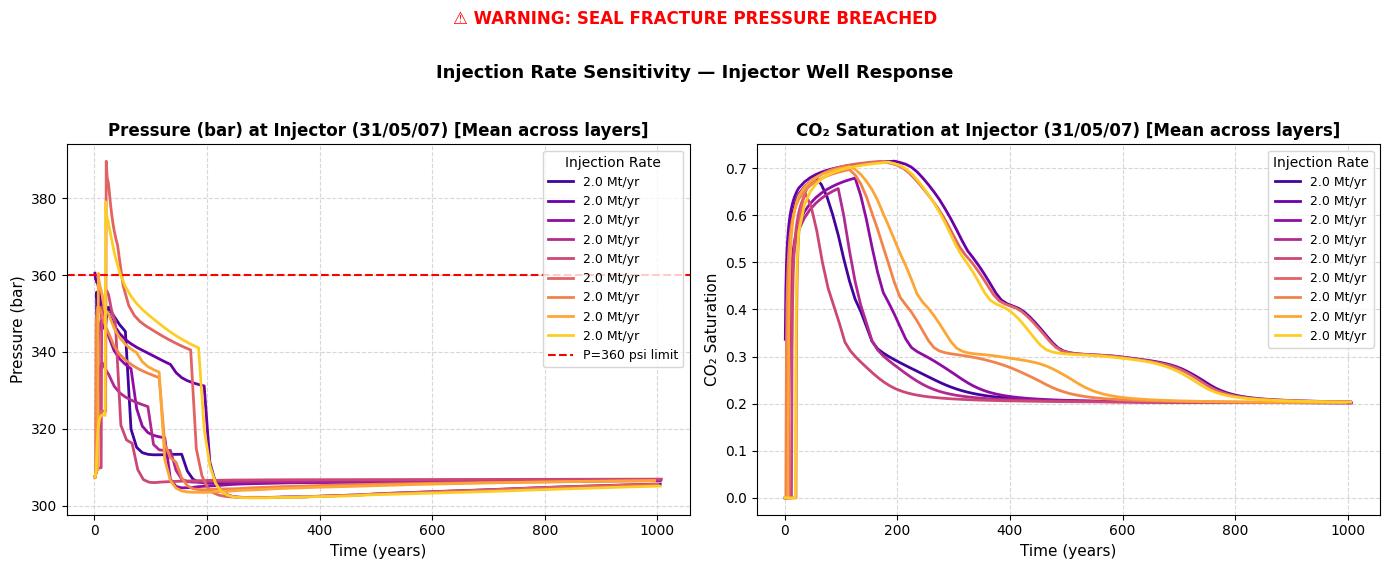

In [4]:
# ── 3. Injection Rate Sensitivity — Injector Well (Mean) ──────────────────
INJ_WELL = '31/05/07'
palette  = cm.plasma(np.linspace(0.1, 0.9, len(runs)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, col, ylabel in zip(axes, ['Pressure_bar','CO2_Saturation'], ['Pressure (bar)','CO₂ Saturation']):
    for i, (rf, rd) in enumerate(runs.items()):
        if INJ_WELL in rd['dfs']:
            df = rd['dfs'][INJ_WELL]
            ax.plot(df['Time_yr'], df[col], color=palette[i], linewidth=2, label=rd['label'])
    ax.set_xlabel('Time (years)', fontsize=11)
    if 'Pressure' in ylabel:
        ax.axhline(360, color='red', ls='--', lw=1.5, label='P=360 psi limit')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, ls='--', alpha=0.5)
    ax.legend(title='Injection Rate', fontsize=9)
    ax.set_title(f'{ylabel} at Injector ({INJ_WELL}) [Mean across layers]', fontweight='bold')

plt.suptitle('Injection Rate Sensitivity — Injector Well Response', fontsize=13, fontweight='bold', y=1.02)

breached = any(rd['dfs'][INJ_WELL]['Pressure_bar'].max() > 360 for rd in runs.values() if INJ_WELL in rd['dfs'])
if breached:
    fig.text(0.5, 1.10, '⚠️ WARNING: SEAL FRACTURE PRESSURE BREACHED', ha='center', color='red', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

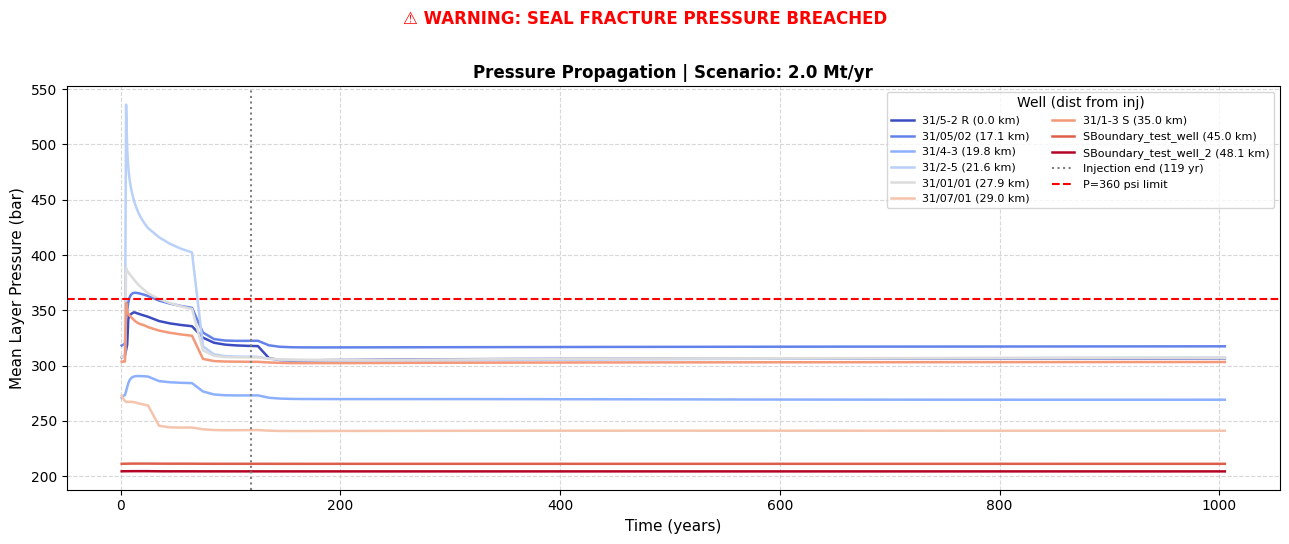

In [5]:
# ── 4. Pressure Propagation Across Unique Observation Wells (Mean) ────────
ref_run = list(runs.keys())[0]
seen, unique_obs = set(), []
for wname, winfo in runs[ref_run]['obs_wells'].items():
    cell = (winfo['GridI'], winfo['GridJ'])
    if cell not in seen:
        seen.add(cell)
        d = math.sqrt((winfo['GridI']-51)**2 + (winfo['GridJ']-51)**2)
        unique_obs.append((wname, winfo['depth_m'], d * 0.9))
unique_obs.sort(key=lambda x: x[2])

mid_run = list(runs.keys())[min(2, len(runs)-1)] # Safe pick
mid_rd  = runs[mid_run]
palette_obs = cm.coolwarm(np.linspace(0, 1, len(unique_obs)))

fig, ax = plt.subplots(figsize=(13, 5))
for i, (wname, depth, d_km) in enumerate(unique_obs):
    if wname in mid_rd['dfs']:
        df = mid_rd['dfs'][wname]
        ax.plot(df['Time_yr'], df['Pressure_bar'], color=palette_obs[i],
                linewidth=1.8, label=f'{wname} ({d_km:.1f} km)')
try:
    ie = float(mid_rd['meta'].get('inj_end', '50').split()[0])
    ax.axvline(ie, color='gray', ls=':', lw=1.5, label=f'Injection end ({ie:.0f} yr)')
except: pass
ax.set_xlabel('Time (years)', fontsize=11)
ax.axhline(360, color='red', ls='--', lw=1.5, label='P=360 psi limit')
ax.set_ylabel('Mean Layer Pressure (bar)', fontsize=11)
ax.set_title(f'Pressure Propagation | Scenario: {mid_rd["label"]}', fontweight='bold')
ax.legend(title='Well (dist from inj)', fontsize=8, loc='upper right', ncol=2)
ax.grid(True, ls='--', alpha=0.5)

breached = False
for wname, _, _ in unique_obs:
    if wname in mid_rd['dfs'] and mid_rd['dfs'][wname]['Pressure_bar'].max() > 360:
        breached = True
if breached:
    fig.text(0.5, 1.05, '⚠️ WARNING: SEAL FRACTURE PRESSURE BREACHED', ha='center', color='red', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

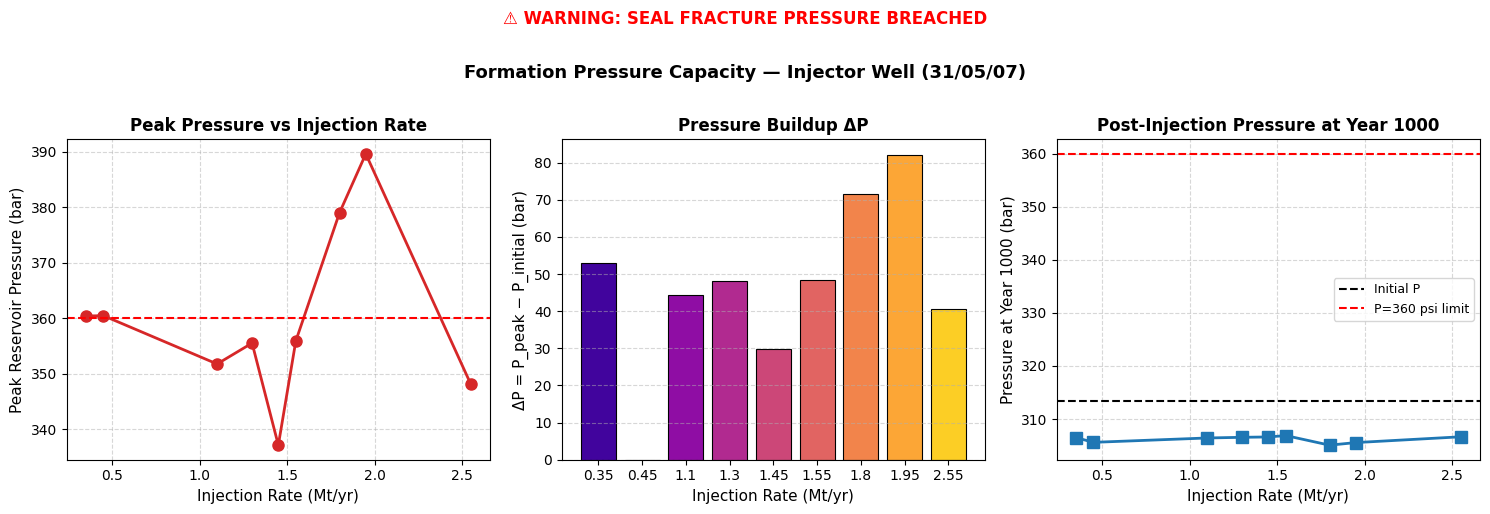

In [6]:
# ── 5. Formation Capacity Analysis ─────────────────────────────────────────
cap_data = []
for rf, rd in runs.items():
    if not rd['active_wells']: continue
    rate_val = list(rd['active_wells'].values())[0]['rate_mtyr']
    if INJ_WELL in rd['dfs']:
        df    = rd['dfs'][INJ_WELL]
        p0    = df['Pressure_bar'].iloc[0]
        pmax  = df['Pressure_bar'].max()
        pfin  = df['Pressure_bar'].iloc[-1]
        try:    co2 = float(rd['meta'].get('co2_total','0').split()[0])
        except: co2 = 0.0
        cap_data.append({'Rate': rate_val, 'P_init': p0, 'P_peak': pmax, 'P_final': pfin, 'dP': pmax-p0, 'CO2_Mt': co2})

df_cap = pd.DataFrame(cap_data).sort_values('Rate')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(df_cap['Rate'], df_cap['P_peak'], 'o-', color='#d62728', lw=2, markersize=8)
axes[0].set_xlabel('Injection Rate (Mt/yr)', fontsize=11)
axes[0].axhline(360, color='red', ls='--', lw=1.5, label='P=360 psi limit')
axes[0].set_ylabel('Peak Reservoir Pressure (bar)', fontsize=11)
axes[0].set_title('Peak Pressure vs Injection Rate', fontweight='bold')
axes[0].grid(True, ls='--', alpha=0.5)

axes[1].bar(df_cap['Rate'].astype(str), df_cap['dP'],
            color=cm.plasma(np.linspace(0.1, 0.9, len(df_cap))), edgecolor='k', linewidth=0.8)
axes[1].set_xlabel('Injection Rate (Mt/yr)', fontsize=11)
axes[1].set_ylabel('ΔP = P_peak − P_initial (bar)', fontsize=11)
axes[1].set_title('Pressure Buildup ΔP', fontweight='bold')
axes[1].grid(True, ls='--', alpha=0.5, axis='y')

axes[2].plot(df_cap['Rate'], df_cap['P_final'], 's-', color='#1f77b4', lw=2, markersize=8)
axes[2].axhline(df_cap['P_init'].mean(), color='k', ls='--', label='Initial P')
axes[2].set_xlabel('Injection Rate (Mt/yr)', fontsize=11)
axes[2].axhline(360, color='red', ls='--', lw=1.5, label='P=360 psi limit')
axes[2].set_ylabel('Pressure at Year 1000 (bar)', fontsize=11)
axes[2].set_title('Post-Injection Pressure at Year 1000', fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, ls='--', alpha=0.5)

plt.suptitle('Formation Pressure Capacity — Injector Well (31/05/07)', fontsize=13, fontweight='bold', y=1.01)

if df_cap['P_peak'].max() > 360:
    fig.text(0.5, 1.10, '⚠️ WARNING: SEAL FRACTURE PRESSURE BREACHED', ha='center', color='red', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

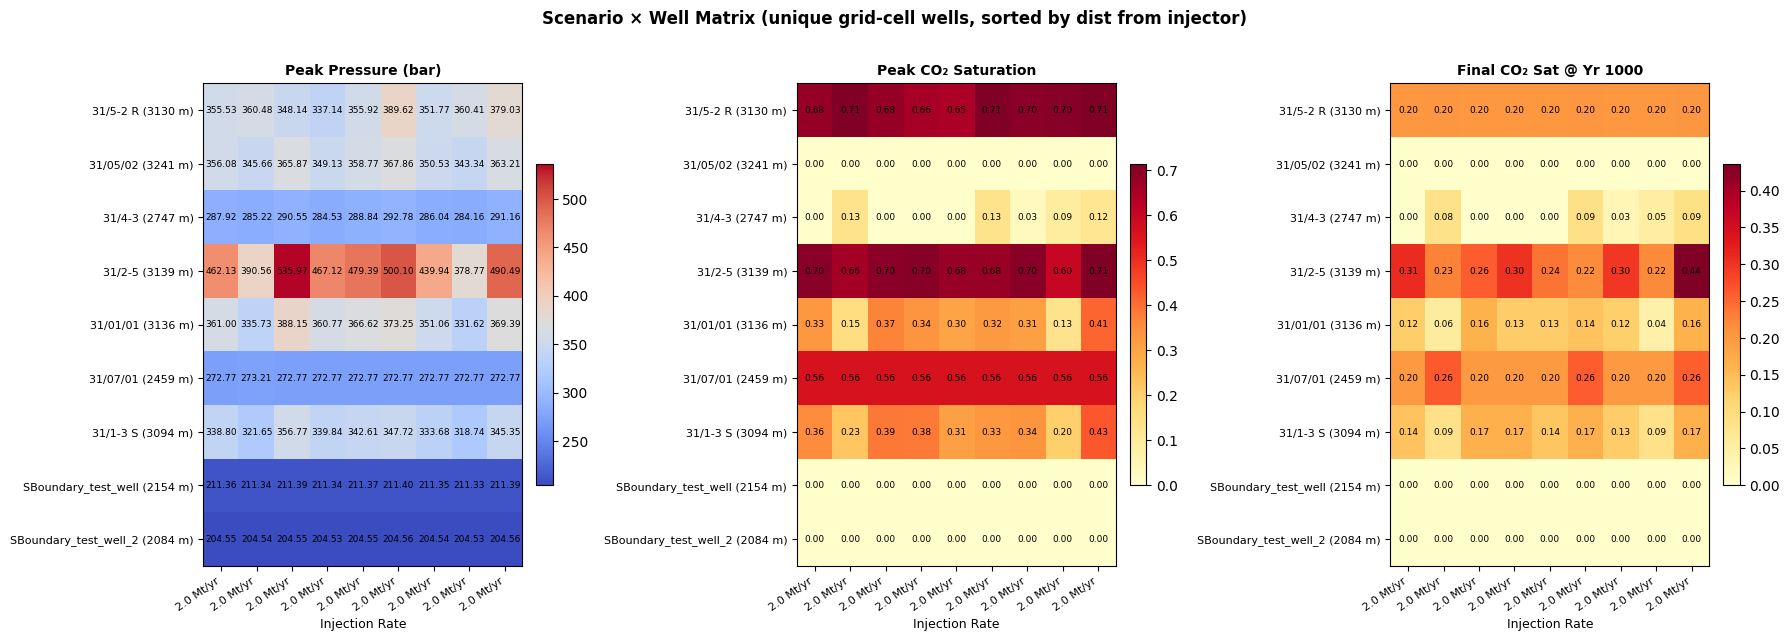

In [7]:
# ── 6. Scenario × Well Heatmap (Mean Layers) ──────────────────────────────
unique_wells_hm = [(w, d) for w, d, _ in unique_obs]
rate_labels_hm  = [rd['label'] for rd in runs.values()]
n_w, n_r = len(unique_wells_hm), len(runs)

hm_pp = np.full((n_w, n_r), np.nan)
hm_sp = np.full((n_w, n_r), np.nan)
hm_sf = np.full((n_w, n_r), np.nan)

for j, (_, rd) in enumerate(runs.items()):
    for i, (wname, _) in enumerate(unique_wells_hm):
        if wname in rd['dfs']:
            df = rd['dfs'][wname]
            hm_pp[i,j] = df['Pressure_bar'].max()
            hm_sp[i,j] = df['CO2_Saturation'].max()
            hm_sf[i,j] = df['CO2_Saturation'].iloc[-1]

y_labels = [f'{w} ({d:.0f} m)' for w, d in unique_wells_hm]
fig, axes = plt.subplots(1, 3, figsize=(18, max(5, n_w*0.7)))
for ax, data, title, cmap in zip(axes,
    [hm_pp, hm_sp, hm_sf],
    ['Peak Pressure (bar)', 'Peak CO₂ Saturation', 'Final CO₂ Sat @ Yr 1000'],
    ['coolwarm', 'YlOrRd', 'YlOrRd']):
    im = ax.imshow(data, aspect='auto', cmap=cmap)
    ax.set_xticks(range(n_r))
    ax.set_xticklabels(rate_labels_hm, rotation=35, ha='right', fontsize=8)
    ax.set_yticks(range(n_w))
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Injection Rate', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for ii in range(n_w):
        for jj in range(n_r):
            if not np.isnan(data[ii,jj]):
                ax.text(jj, ii, f'{data[ii,jj]:.2f}', ha='center', va='center', fontsize=6.5)
plt.suptitle('Scenario × Well Matrix (unique grid-cell wells, sorted by dist from injector)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

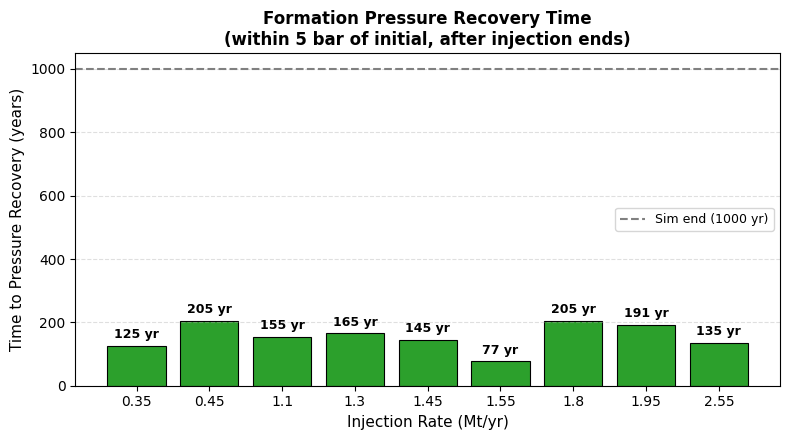

In [8]:
# ── 7. Pressure Recovery Time ──────────────────────────────────────────────
relax_data = []
for rf, rd in runs.items():
    if not rd['active_wells']: continue
    rate_val = list(rd['active_wells'].values())[0]['rate_mtyr']
    if INJ_WELL not in rd['dfs']: continue
    df = rd['dfs'][INJ_WELL]
    p0 = df['Pressure_bar'].iloc[0]
    pmax = df['Pressure_bar'].max()
    try:    ie = float(rd['meta'].get('inj_end','50').split()[0])
    except: ie = 50.0
    post = df[df['Time_yr'] > ie]
    rec  = post[post['Pressure_bar'] <= p0 + 5.0]
    t_rec = rec['Time_yr'].iloc[0] if not rec.empty else None
    relax_data.append({'Rate': rate_val, 'dP': pmax - p0, 'T_recover_yr': t_rec})

df_relax = pd.DataFrame(relax_data).sort_values('Rate')
colors   = ['#2ca02c' if t is not None else '#d62728' for t in df_relax['T_recover_yr']]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(df_relax['Rate'].astype(str), df_relax['T_recover_yr'].fillna(1050),
       color=colors, edgecolor='k', lw=0.8)
ax.axhline(1000, color='gray', ls='--', label='Sim end (1000 yr)')
ax.set_xlabel('Injection Rate (Mt/yr)', fontsize=11)
ax.set_ylabel('Time to Pressure Recovery (years)', fontsize=11)
ax.set_title('Formation Pressure Recovery Time\n(within 5 bar of initial, after injection ends)', fontweight='bold')
for idx_row, row in df_relax.iterrows():
    t_str = f"{row['T_recover_yr']:.0f} yr" if row['T_recover_yr'] else 'Not recovered'
    bar_i = list(df_relax['Rate']).index(row['Rate'])
    ax.text(bar_i, (row['T_recover_yr'] or 1050) + 15, t_str,
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, ls='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

In [9]:
# ── 8. Interactive Multi-Well Explorer (Layer Selection) ──────────────────
all_unique_wells_exp = sorted(set(w for rd in runs.values() for w in rd['dfs'].keys()))
run_labels = {rf: f"{rd['label']} ({rf})" for rf, rd in runs.items()}

w_run = widgets.Dropdown(
    options=[(v,k) for k,v in run_labels.items()],
    description='Scenario:', style={'description_width':'initial'}, layout=widgets.Layout(width='50%')
)
w_wells = widgets.SelectMultiple(
    options=all_unique_wells_exp, value=[all_unique_wells_exp[0]],
    description='Wells:', style={'description_width':'initial'}, layout=widgets.Layout(width='50%', height='130px')
)
w_metric = widgets.RadioButtons(
    options=['Pressure', 'CO2 Saturation', 'Both'], value='Both',
    description='Show:', style={'description_width':'initial'}
)
w_layer_exp = widgets.Dropdown(
    options=['Mean All Layers', 'Layer 6', 'Layer 7', 'Layer 8', 'Layer 9', 'Layer 10'], 
    value='Mean All Layers', description='Layer:', style={'description_width':'initial'}
)
w_compare = widgets.Checkbox(
    value=False, description='Compare across ALL scenarios', style={'description_width':'initial'}
)
out_exp = widgets.Output()

def update_explorer(change=None):
    with out_exp:
        clear_output(wait=True)
        sel_run, sel_wells, metric, compare, layer_sel = w_run.value, list(w_wells.value), w_metric.value, w_compare.value, w_layer_exp.value
        if not sel_wells:
            print('Select at least one well.'); return

        n_rows = 2 if metric == 'Both' else 1
        fig, axes = plt.subplots(n_rows, 1, figsize=(12, 4*n_rows), sharex=True)
        if n_rows == 1: axes = [axes]
        pal = plt.cm.tab10.colors

        title_suffix = '(Mean over layers)' if layer_sel == 'Mean All Layers' else f'({layer_sel})'
        
        def get_col(df, base_col):
            if layer_sel == 'Mean All Layers':
                return df[base_col]
            else:
                k = layer_sel.split()[-1]
                c = f"P_bar_L{k}" if base_col == 'Pressure_bar' else f"S_CO2_L{k}"
                return df[c] if c in df.columns else np.full(len(df), np.nan)

        if compare:
            for wi, wname in enumerate(sel_wells):
                for ri, (rf, rd) in enumerate(runs.items()):
                    if wname not in rd['dfs']: continue
                    df = rd['dfs'][wname]
                    ls = ['-','--',':','-.'][ri%4]
                    lbl = f'{wname} @ {rd["label"]}'
                    if metric in ('Pressure','Both'):
                        axes[0].plot(df['Time_yr'], get_col(df, 'Pressure_bar'), ls, color=pal[wi%10], lw=1.8, label=lbl)
                    if metric in ('CO2 Saturation','Both'):
                        axes[-1].plot(df['Time_yr'], get_col(df, 'CO2_Saturation'), ls, color=pal[wi%10], lw=1.8, label=lbl)
            title = f'Cross-Scenario Comparison — Selected Wells {title_suffix}'
        else:
            rd = runs[sel_run]
            for wi, wname in enumerate(sel_wells):
                if wname not in rd['dfs']: continue
                df = rd['dfs'][wname]
                if metric in ('Pressure','Both'):
                    axes[0].plot(df['Time_yr'], get_col(df, 'Pressure_bar'), color=pal[wi%10], lw=2, label=wname)
                if metric in ('CO2 Saturation','Both'):
                    axes[-1].plot(df['Time_yr'], get_col(df, 'CO2_Saturation'), color=pal[wi%10], lw=2, label=wname)
            title = f'Scenario: {run_labels[sel_run]} {title_suffix}'

        metrics_used = ['Pressure','CO2 Saturation'] if metric=='Both' else [metric]
        for ax, m in zip(axes, metrics_used):
            if 'Pressure' in m:
                ax.axhline(360, color='red', ls='--', lw=1.5, label='P=360 psi limit')
            ax.set_ylabel(m, fontsize=11)
            ax.grid(True, ls='--', alpha=0.5)
            ax.legend(fontsize=8, loc='upper right', ncol=2)
        axes[-1].set_xlabel('Time (years)', fontsize=11)
        
        breached = False
        if metric in ('Pressure', 'Both'):
            if compare:
                for wname in sel_wells:
                    for rd in runs.values():
                        if wname in rd['dfs'] and get_col(rd['dfs'][wname], 'Pressure_bar').max() > 360:
                            breached = True
            else:
                for wname in sel_wells:
                    if wname in runs[sel_run]['dfs'] and get_col(runs[sel_run]['dfs'][wname], 'Pressure_bar').max() > 360:
                        breached = True
                        
        if breached:
            plt.suptitle(title + '\n⚠️ WARNING: SEAL FRACTURE PRESSURE BREACHED', fontsize=12, fontweight='bold', color='red')
        else:
            plt.suptitle(title, fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.show()

for w in [w_run, w_wells, w_metric, w_compare, w_layer_exp]:
    w.observe(update_explorer, names='value')

display(widgets.VBox([
    widgets.HTML('<h3>Section 8 — Interactive Multi-Well Explorer</h3>'),
    widgets.HBox([w_run, w_layer_exp]),
    widgets.HBox([w_wells, widgets.VBox([w_metric, w_compare])]),
    out_exp
]))
update_explorer()